# `Holiday Package Prediction`
## 1- Problem Statement
"Trips & Travel.com" Company wants to enable and establish a viable business model to expand the customer base. One of the ways to expand the customer base is to introduce a new offering of packages. Currently, there are `5 types` of packages the company is offering, `Basic`, `Standard`,`Deluxe`, `Super Deluxe`,`King`. Looking at the data of the last year, we observed that `18%` of the customers purchased the packages. However, the marketing cost was quite high because customers were contracted at random without looking at the available information. The company now planning to launch a new product i.e `Wellness Tourism Package.`  Wellness Tourism is defined as Travel that allows the traveler to maintain, enhance or kick-start a healthy lifestyle. and support or increase one's sense of well-being. However, this time company wants to harness the available data of existing and potential customers to make the marketing expenditure more efficient.


## 2- Data Collection
The Dataset is collected from  https://www.kaggle.com/datasets/susant4learning/holiday-package-purchase-prediction  The data consists of 20 column and 4888 rows.

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import warnings
warnings.filterwarnings('ignore')


In [3]:
df = pd.read_csv('../09. RandomForest/Travel.csv')
df.head()

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,NaN,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


# `Aim`
The company wants to `launch new product by the name (wireless product)`, on the basis of given data we have to classify whether or not they launch the product.

# `Feature Engineering part-1`

### 1- Data Cleaning
1. Handling Missing Values
2. Handling Duplicate Values
3. Check data type
4. Understand the dataset

In [4]:
## checking missing value
df.isnull().sum().sort_values(ascending=False)

DurationOfPitch             251
MonthlyIncome               233
Age                         226
NumberOfTrips               140
NumberOfChildrenVisiting     66
NumberOfFollowups            45
PreferredPropertyStar        26
TypeofContact                25
CustomerID                    0
ProdTaken                     0
Gender                        0
CityTier                      0
ProductPitched                0
NumberOfPersonVisiting        0
Occupation                    0
MaritalStatus                 0
PitchSatisfactionScore        0
Passport                      0
OwnCar                        0
Designation                   0
dtype: int64

1- `We have missing values in 8 columns see above`

In [5]:
## Checking issues in categorical columns as well as the count of each category
categorical_col = [col for col in df.columns if df[col].dtype =='O']
nummerical_col = [col for col in df.columns if df[col].dtype !='O']

In [6]:
## these are the categorical columns 
categorical_col

['TypeofContact',
 'Occupation',
 'Gender',
 'ProductPitched',
 'MaritalStatus',
 'Designation']

In [7]:
### these are the numerical columns
nummerical_col

['CustomerID',
 'ProdTaken',
 'Age',
 'CityTier',
 'DurationOfPitch',
 'NumberOfPersonVisiting',
 'NumberOfFollowups',
 'PreferredPropertyStar',
 'NumberOfTrips',
 'Passport',
 'PitchSatisfactionScore',
 'OwnCar',
 'NumberOfChildrenVisiting',
 'MonthlyIncome']

In [8]:
### total number of categorical and numerical columns are 
print('Total categorical col:',len(categorical_col)) 
print('Total Numerical col:',len(nummerical_col)) 

Total categorical col: 6
Total Numerical col: 14


In [9]:
## Gender columns 
df['Gender'].value_counts()
    
    

Gender
Male       2916
Female     1817
Fe Male     155
Name: count, dtype: int64

2-`The problem over here is Female category occur two times due to spelling mistakes, we need to combine them`

In [10]:
## 
print(categorical_col)

['TypeofContact', 'Occupation', 'Gender', 'ProductPitched', 'MaritalStatus', 'Designation']


In [11]:
## TypeofContract column
df['TypeofContact'].value_counts()

TypeofContact
Self Enquiry       3444
Company Invited    1419
Name: count, dtype: int64

In [12]:
## 'Occupation' 
df['Occupation'].value_counts()

Occupation
Salaried          2368
Small Business    2084
Large Business     434
Free Lancer          2
Name: count, dtype: int64

In [13]:
### ProductPicted column
df['ProductPitched'].value_counts()

ProductPitched
Basic           1842
Deluxe          1732
Standard         742
Super Deluxe     342
King             230
Name: count, dtype: int64

In [14]:
## Marital Status column
df['MaritalStatus'].value_counts()

MaritalStatus
Married      2340
Divorced      950
Single        916
Unmarried     682
Name: count, dtype: int64

3. `The category 'single' and 'Unmarried' occur both we need to combine them as single category`

In [15]:
### Designation column
df['Designation'].value_counts()

Designation
Executive         1842
Manager           1732
Senior Manager     742
AVP                342
VP                 230
Name: count, dtype: int64

- `Solution:`
`As above two categorical columns has issues, we now correct them`
1. Gender 
2. MaritalStatus

In [16]:
df['Gender'] = df['Gender'].replace('Fe Male','Female')
df['MaritalStatus'] = df['MaritalStatus'].replace('Single','Unmarried')

In [17]:
 ## now the problem solved here
df['Gender'].value_counts() 

Gender
Male      2916
Female    1972
Name: count, dtype: int64

In [18]:
## Here also the problem solved
df['MaritalStatus'].value_counts()

MaritalStatus
Married      2340
Unmarried    1598
Divorced      950
Name: count, dtype: int64

### Checking Missing Values

In [19]:
## Checking missing values

feature_with_nan = [feature for feature in df.columns if df[feature].isnull().sum() >= 1]
for feature in feature_with_nan:
    print(feature,':',np.round(df[feature].isnull().mean()*100,5),'% Missing Values')

Age : 4.62357 % Missing Values
TypeofContact : 0.51146 % Missing Values
DurationOfPitch : 5.13502 % Missing Values
NumberOfFollowups : 0.92062 % Missing Values
PreferredPropertyStar : 0.53191 % Missing Values
NumberOfTrips : 2.86416 % Missing Values
NumberOfChildrenVisiting : 1.35025 % Missing Values
MonthlyIncome : 4.76678 % Missing Values


In [20]:
## Statistics on numerical columns (Null Cols)
df[feature_with_nan].select_dtypes(exclude='object').describe()

,Age,DurationOfPitch,NumberOfFollowups,PreferredPropertyStar,NumberOfTrips,NumberOfChildrenVisiting,MonthlyIncome
count,4662.000000,4637.000000,4843.000000,4862.000000,4748.000000,4822.000000,4655.000000
mean,37.622265,15.490835,3.708445,3.581037,3.236521,1.187267,23619.853491
std,9.316387,8.519643,1.002509,0.798009,1.849019,0.857861,5380.698361
min,18.000000,5.000000,1.000000,3.000000,1.000000,0.000000,1000.000000
25%,31.000000,9.000000,3.000000,3.000000,2.000000,1.000000,20346.000000
50%,36.000000,13.000000,4.000000,3.000000,3.000000,1.000000,22347.000000
75%,44.000000,20.000000,4.000000,4.000000,4.000000,2.000000,25571.000000
max,61.000000,127.000000,6.000000,5.000000,22.000000,3.000000,98678.000000


### Imputing Null Values
1. Impute Median Values for `Age` column
2. Impute Mode for `Type of Contract`
3. Impute Median for `Duration of Pitch` 
4. Impute Mode for `NumberofFollowup` as it is `Descrete feature`(if categories is more than 10,20 30 etc that is called descrete feature)
5. Impute Mode for `PreferredPropertyStar`
6. Impute Median for `NumberofTrips`
7. Impute Mode for `NumberOfChildrenVisiting`
8. Impute Median for `MonthlyIncome`

In [21]:
## Age 
df.Age.fillna(df.Age.median(),inplace=True)

## TypeofContract
df.TypeofContact.fillna(df.TypeofContact.mode()[0],inplace=True)

## Duration of Pitch
df.DurationOfPitch.fillna(df.DurationOfPitch.median(),inplace=True)

## NumberOfFollowups
df.NumberOfFollowups.fillna(df.NumberOfFollowups.mode()[0],inplace=True)

## PreferredPropertyStar
df.PreferredPropertyStar.fillna(df.PreferredPropertyStar.mode()[0],inplace=True)

## NumberOfTrips
df.NumberOfTrips.fillna(df.NumberOfTrips.median(),inplace=True)

## NumberOfChildrenVisiting
df.NumberOfChildrenVisiting.fillna(df.NumberOfChildrenVisiting.mode()[0],inplace=True)

## MonthlyIncome
df.MonthlyIncome.fillna(df.MonthlyIncome.median(),inplace=True)

In [22]:
df.isnull().sum()

CustomerID                  0
ProdTaken                   0
Age                         0
TypeofContact               0
CityTier                    0
DurationOfPitch             0
Occupation                  0
Gender                      0
NumberOfPersonVisiting      0
NumberOfFollowups           0
ProductPitched              0
PreferredPropertyStar       0
MaritalStatus               0
NumberOfTrips               0
Passport                    0
PitchSatisfactionScore      0
OwnCar                      0
NumberOfChildrenVisiting    0
Designation                 0
MonthlyIncome               0
dtype: int64

### `As we have perfectly Fill the Missing Values in  Our Data Over Here Now`

In [23]:
df.columns

Index(['CustomerID', 'ProdTaken', 'Age', 'TypeofContact', 'CityTier',
       'DurationOfPitch', 'Occupation', 'Gender', 'NumberOfPersonVisiting',
       'NumberOfFollowups', 'ProductPitched', 'PreferredPropertyStar',
       'MaritalStatus', 'NumberOfTrips', 'Passport', 'PitchSatisfactionScore',
       'OwnCar', 'NumberOfChildrenVisiting', 'Designation', 'MonthlyIncome'],
      dtype='object')

In [24]:
### As CustomerID column is not that important so we remove it 
df.drop('CustomerID',axis=1,inplace=True)

In [25]:
df.head()

,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Unmarried,1.0,1,2,1,0.0,Manager,20993.0
1,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Unmarried,7.0,1,3,0,0.0,Executive,17090.0
3,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,0,36.0,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


# **Feature Engineering**

### `Feature Extraction`

In [26]:
### Creating New Column for feature by combining two feature which also reduce the total no of columns
df['TotalVisiting'] = df['NumberOfChildrenVisiting'] + df['NumberOfPersonVisiting']

## Now we remove the two separate columns we don't need them anymore
df.drop(columns=['NumberOfChildrenVisiting','NumberOfPersonVisiting'],axis=1,inplace=True)


In [27]:
df.head()

,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,Designation,MonthlyIncome,TotalVisiting
0,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3.0,Deluxe,3.0,Unmarried,1.0,1,2,1,Manager,20993.0,3.0
1,0,49.0,Company Invited,1,14.0,Salaried,Male,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,Manager,20130.0,5.0
2,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,4.0,Basic,3.0,Unmarried,7.0,1,3,0,Executive,17090.0,3.0
3,0,33.0,Company Invited,1,9.0,Salaried,Female,3.0,Basic,3.0,Divorced,2.0,1,5,1,Executive,17909.0,3.0
4,0,36.0,Self Enquiry,1,8.0,Small Business,Male,3.0,Basic,4.0,Divorced,1.0,0,5,1,Executive,18468.0,2.0


In [28]:
## to get the total Numerical feature 

nummerical_features = [feature for feature in df.columns if df[feature].dtype !='O']
print('Total Numerical Features are:',len(nummerical_features))

Total Numerical Features are: 12


In [29]:
## to get the total Categorical feature 

categorical_features = [feature for feature in df.columns if df[feature].dtype =='O']
print('Total Categorical Features are:',len(categorical_features))

Total Categorical Features are: 6


In [30]:
## Descrete Features 
discrete_features = [feature for feature in nummerical_features if len(df[feature].unique()) <=25]
print('Num of Descrete Features :',len(discrete_features))

Num of Descrete Features : 9


In [31]:
## Continuous Features 
continuous_features = [feature for feature in nummerical_features if feature not in discrete_features]
print('Continuous Features :',len(continuous_features))

Continuous Features : 3


In [32]:
### Now our dataframe look like this 
df.head()

,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,Designation,MonthlyIncome,TotalVisiting
0,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3.0,Deluxe,3.0,Unmarried,1.0,1,2,1,Manager,20993.0,3.0
1,0,49.0,Company Invited,1,14.0,Salaried,Male,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,Manager,20130.0,5.0
2,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,4.0,Basic,3.0,Unmarried,7.0,1,3,0,Executive,17090.0,3.0
3,0,33.0,Company Invited,1,9.0,Salaried,Female,3.0,Basic,3.0,Divorced,2.0,1,5,1,Executive,17909.0,3.0
4,0,36.0,Self Enquiry,1,8.0,Small Business,Male,3.0,Basic,4.0,Divorced,1.0,0,5,1,Executive,18468.0,2.0


In [33]:
## There are still Preprocessing needed

# `Feature Engineering part-2`

#### `Now we convert all the categorical values into Numerical`

In [34]:
### Before we convert we need to do train test split
from sklearn.model_selection import train_test_split

# Independent features are 
X = df.drop(['ProdTaken'],axis=1)
y = df['ProdTaken']

In [35]:
X.head(2)

,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,Designation,MonthlyIncome,TotalVisiting
0,41.0,Self Enquiry,3,6.0,Salaried,Female,3.0,Deluxe,3.0,Unmarried,1.0,1,2,1,Manager,20993.0,3.0
1,49.0,Company Invited,1,14.0,Salaried,Male,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,Manager,20130.0,5.0


In [36]:
y.head()

0    1
1    0
2    1
3    0
4    0
Name: ProdTaken, dtype: int64

In [37]:
### To check the balanceness of data
y.value_counts()

ProdTaken
0    3968
1     920
Name: count, dtype: int64

#### `The data is imbalance but, for any ensemble techniques i.e random forest this is no issue weather the data is balance or not, these algorithm still perform better on such data`

In [38]:
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=.2,random_state=42)

X_train.shape,X_test.shape

((3910, 17), (978, 17))

In [39]:
## Creating Column transformer with 3 types of transformers 

cat_features = X.select_dtypes(include='object').columns
num_features = X.select_dtypes(exclude='object').columns

from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder(drop='first')

preprocessor = ColumnTransformer(
    [
        ('OneHotEncoder',oh_transformer,cat_features),
        ('StandardScaler',numeric_transformer,num_features)
    ]
)

* `In random forest we don't need to do scaling but here we want to understand the working of Column transformer what's why we have done scaling also`

In [40]:
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('OneHotEncoder', ...), ('StandardScaler', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``f

`Applying Transformation on Training dataset--> use (fit_transform)`

In [41]:
## Applying Transformation on Training dataset--> use (fit_transform)
X_train = preprocessor.fit_transform(X_train)
X_train

array([[ 1.        ,  0.        ,  0.        , ...,  0.78296635,
        -0.38224537, -0.77415132],
       [ 1.        ,  0.        ,  1.        , ...,  0.78296635,
        -0.4597992 ,  0.64361526],
       [ 1.        ,  1.        ,  0.        , ...,  0.78296635,
        -0.24519557, -0.06526803],
       ...,
       [ 0.        ,  0.        ,  0.        , ...,  0.78296635,
        -0.36057591,  0.64361526],
       [ 1.        ,  0.        ,  0.        , ...,  0.78296635,
        -0.25279888,  0.64361526],
       [ 0.        ,  0.        ,  1.        , ..., -1.2771941 ,
        -1.08251091, -1.48303461]], shape=(3910, 26))

In [42]:
### checking in dataframe form
pd.DataFrame(X_train)

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,-0.721400,-1.020350,1.284279,-0.725271,-0.127737,-0.632399,0.679690,0.782966,-0.382245,-0.774151
1,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,-0.721400,0.690023,0.282777,-0.725271,1.511598,-0.632399,0.679690,0.782966,-0.459799,0.643615
2,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.721400,-1.020350,0.282777,1.771041,0.418708,-0.632399,0.679690,0.782966,-0.245196,-0.065268
3,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,...,-0.721400,-1.020350,1.284279,-0.725271,-0.127737,-0.632399,1.408395,-1.277194,0.213475,-0.065268
4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.721400,2.400396,-1.720227,-0.725271,1.511598,-0.632399,-0.049015,-1.277194,-0.024889,2.061382
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3905,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,-0.721400,-0.653841,1.284279,-0.725271,-0.674182,-0.632399,-1.506426,0.782966,-0.536973,0.643615
3906,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,1.455047,-0.898180,-0.718725,1.771041,-1.220627,-0.632399,1.408395,0.782966,1.529609,-0.065268
3907,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.455047,1.545210,0.282777,-0.725271,2.058043,-0.632399,-0.777720,0.782966,-0.360576,0.643615
3908,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,...,1.455047,1.789549,1.284279,-0.725271,-0.127737,-0.632399,-1.506426,0.782966,-0.252799,0.643615


`Applying Transformation on test data --> use (transform)`

In [43]:
## Transforming the test data
X_test = preprocessor.transform(X_test)

* We only use `transform` only instead of `fit_transform` because of `data leakage`, because we `don't want that the model know any thing about the test data`

In [44]:
X_test

array([[ 0.        ,  0.        ,  0.        , ..., -1.2771941 ,
        -0.73751038, -0.77415132],
       [ 1.        ,  0.        ,  0.        , ..., -1.2771941 ,
        -0.6704111 , -0.06526803],
       [ 1.        ,  0.        ,  0.        , ...,  0.78296635,
        -0.4208322 , -0.77415132],
       ...,
       [ 0.        ,  1.        ,  0.        , ...,  0.78296635,
         0.69001249,  0.64361526],
       [ 1.        ,  0.        ,  0.        , ...,  0.78296635,
        -0.22827818, -0.77415132],
       [ 1.        ,  1.        ,  0.        , ...,  0.78296635,
        -0.44611323,  2.06138184]], shape=(978, 26))

# `AdaBoost Classifer Training`

In [45]:
## importing libraries
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import AdaBoostClassifier
## Gradient Bossting
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,\
                            ConfusionMatrixDisplay,precision_score,recall_score,f1_score,\
                            roc_auc_score,roc_curve

`Efficient Way of Model Training`

In [46]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest":RandomForestClassifier(),
    'AdaBoost':AdaBoostClassifier(),
    'GradientBoosting':GradientBoostingClassifier()
    
}
for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train,y_train)  ## Training the model
    
    ## Make Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    ## Training set Performance 
    model_train_accuracy = accuracy_score(y_train,y_train_pred)
    model_train_f1 = f1_score(y_train,y_train_pred,average='weighted')
    model_train_precision = precision_score(y_train,y_train_pred)
    model_train_recall = recall_score(y_train,y_train_pred)
    model_train_rocauc_score = roc_auc_score(y_train,y_train_pred)
    
    
    ## Test Set Performance 
    model_test_accuracy = accuracy_score(y_test,y_test_pred)
    model_test_f1 = f1_score(y_test,y_test_pred,average='weighted')
    model_test_precision = precision_score(y_test,y_test_pred)
    model_test_recall = recall_score(y_test,y_test_pred)
    model_test_rocauc_score = roc_auc_score(y_test,y_test_pred)
    
    print(list(models.keys())[i])
    
    print('Model performance for Training set')
    print('- Accuracy: {:.4f}'.format(model_train_accuracy))
    print('- F1 score: {:.4f}'.format(model_train_f1))
    print('- Precision: {:.4f}'.format(model_train_precision))
    print('- recall: {:.4f}'.format(model_train_recall))
    print('- Roc Auc Score: {:.4f}'.format(model_train_rocauc_score))
    
    
    print('--------------------------------------------')
    
    print('Model performance for Test set')
    print('- Accuracy: {:.4f}'.format(model_test_accuracy))
    print('- F1 score: {:.4f}'.format(model_test_f1))
    print('- Precision: {:.4f}'.format(model_test_precision))
    print('- recall: {:.4f}'.format(model_test_recall))
    print('- Roc Auc Score: {:.4f}'.format(model_test_rocauc_score))
    
    print('='*35)
    print('\n')    

Logistic Regression
Model performance for Training set
- Accuracy: 0.8460
- F1 score: 0.8202
- Precision: 0.7016
- recall: 0.3032
- Roc Auc Score: 0.6368
--------------------------------------------
Model performance for Test set
- Accuracy: 0.8364
- F1 score: 0.8087
- Precision: 0.6914
- recall: 0.2932
- Roc Auc Score: 0.6307


Decision Tree
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- recall: 1.0000
- Roc Auc Score: 1.0000
--------------------------------------------
Model performance for Test set
- Accuracy: 0.9284
- F1 score: 0.9275
- Precision: 0.8380
- recall: 0.7853
- Roc Auc Score: 0.8742


Random Forest
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- recall: 1.0000
- Roc Auc Score: 1.0000
--------------------------------------------
Model performance for Test set
- Accuracy: 0.9254
- F1 score: 0.9194
- Precision: 0.9609
- recall: 0.6440
- Roc Auc Score: 0.8188


AdaBoost
Model perf

#### `How it is an Efficient way:`
* It is an Efficient way because, Now we just need to Import the Algorithm and write inside the `models dectionary` then it will get trained and `show all its corresponding performance in the result` 

* No matter how many algorithm we want to train we just need to import them and initialize inside the model dictionary then everythings will be get done.

* In above we just used `Random forest ` now we import two other algorithm `Logistic Regression ` and `Decision Tree` and check their performances

##### This is how you can train model efficiently 

### `Hyperparameter Tuning of Gradient Bossting Algorithm`

In [57]:
## Hyperparameters 
rf_params = {
    'max_depth':[5,8,15,None,10],
    'max_features':[5,7,'auto',8],
    'min_samples_split':[2,8,15,20],
    'n_estimators':[100,200,500,1000]
}

## Gradient bossting params
gb_params ={
    'loss': ['log_loss', 'exponential'],
    'learning_rate':[0.01,0.1,0.5,1,2],
    'n_estimators':[100,50,20,40,60],
    'criterion':['friedman_mse', 'squared_error'],
    'max_features':['sqrt', 'log2'],    
}


In [58]:
rf_params

{'max_depth': [5, 8, 15, None, 10],
 'max_features': [5, 7, 'auto', 8],
 'min_samples_split': [2, 8, 15, 20],
 'n_estimators': [100, 200, 500, 1000]}

In [59]:
gb_params

{'loss': ['log_loss', 'exponential'],
 'learning_rate': [0.01, 0.1, 0.5, 1, 2],
 'n_estimators': [100, 50, 20, 40, 60],
 'criterion': ['friedman_mse', 'squared_error'],
 'max_features': ['sqrt', 'log2']}

In [66]:
## Models list for Hyperparameter tuning
randomcv_models = [
    ('RandomForest',RandomForestClassifier(),rf_params),
    ('GradientBossting',GradientBoostingClassifier(),gb_params)
]

In [67]:
randomcv_models

[('RandomForest',
  RandomForestClassifier(),
  {'max_depth': [5, 8, 15, None, 10],
   'max_features': [5, 7, 'auto', 8],
   'min_samples_split': [2, 8, 15, 20],
   'n_estimators': [100, 200, 500, 1000]}),
 ('GradientBossting',
  GradientBoostingClassifier(),
  {'loss': ['log_loss', 'exponential'],
   'learning_rate': [0.01, 0.1, 0.5, 1, 2],
   'n_estimators': [100, 50, 20, 40, 60],
   'criterion': ['friedman_mse', 'squared_error'],
   'max_features': ['sqrt', 'log2']})]

In [68]:
from sklearn.model_selection import RandomizedSearchCV

model_param = {}
for name,model,params in randomcv_models:
    random = RandomizedSearchCV(estimator=model,
                                param_distributions=params,
                                n_iter=100,
                                cv=3,
                                verbose=2,
                                n_jobs=-1)
    
    random.fit(X_train,y_train)
    model_param[name] = random.best_params_
    
for model_name in model_param:
    print(f"---------------- Best Params for {model_name} ----------------")
    print(model_param[model_name])
    

Fitting 3 folds for each of 100 candidates, totalling 300 fits
Fitting 3 folds for each of 100 candidates, totalling 300 fits
---------------- Best Params for RandomForest ----------------
{'n_estimators': 1000, 'min_samples_split': 2, 'max_features': 8, 'max_depth': None}
---------------- Best Params for GradientBossting ----------------
{'n_estimators': 100, 'max_features': 'log2', 'loss': 'log_loss', 'learning_rate': 0.5, 'criterion': 'friedman_mse'}


#### `Training Adaboost on Best Parameters`

In [70]:
models = {
    "Random Forest":RandomForestClassifier(n_estimators=1000,min_samples_split=2,max_features=8,max_depth=None),
    "Gradient Boosting":GradientBoostingClassifier(n_estimators= 100, max_features= 'log2', loss= 'log_loss', learning_rate= 0.5, criterion= 'friedman_mse'),
    
}
for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train,y_train)  ## Training the model
    
    ## Make Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    ## Training set Performance 
    model_train_accuracy = accuracy_score(y_train,y_train_pred)
    model_train_f1 = f1_score(y_train,y_train_pred,average='weighted')
    model_train_precision = precision_score(y_train,y_train_pred)
    model_train_recall = recall_score(y_train,y_train_pred)
    model_train_rocauc_score = roc_auc_score(y_train,y_train_pred)
    
    
    ## Test Set Performance 
    model_test_accuracy = accuracy_score(y_test,y_test_pred)
    model_test_f1 = f1_score(y_test,y_test_pred,average='weighted')
    model_test_precision = precision_score(y_test,y_test_pred)
    model_test_recall = recall_score(y_test,y_test_pred)
    model_test_rocauc_score = roc_auc_score(y_test,y_test_pred)
    
    print(list(models.keys())[i])
    
    print('Model performance for Training set')
    print('- Accuracy: {:.4f}'.format(model_train_accuracy))
    print('- F1 score: {:.4f}'.format(model_train_f1))
    print('- Precision: {:.4f}'.format(model_train_precision))
    print('- recall: {:.4f}'.format(model_train_recall))
    print('- Roc Auc Score: {:.4f}'.format(model_train_rocauc_score))
    
    
    print('--------------------------------------------')
    
    print('Model performance for Test set')
    print('- Accuracy: {:.4f}'.format(model_test_accuracy))
    print('- F1 score: {:.4f}'.format(model_test_f1))
    print('- Precision: {:.4f}'.format(model_test_precision))
    print('- recall: {:.4f}'.format(model_test_recall))
    print('- Roc Auc Score: {:.4f}'.format(model_test_rocauc_score))
    
    print('='*35)
    print('\n')    

Random Forest
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- recall: 1.0000
- Roc Auc Score: 1.0000
--------------------------------------------
Model performance for Test set
- Accuracy: 0.9346
- F1 score: 0.9303
- Precision: 0.9635
- recall: 0.6911
- Roc Auc Score: 0.8424


Gradient Boosting
Model performance for Training set
- Accuracy: 0.9202
- F1 score: 0.9149
- Precision: 0.8987
- recall: 0.6447
- Roc Auc Score: 0.8140
--------------------------------------------
Model performance for Test set
- Accuracy: 0.8681
- F1 score: 0.8588
- Precision: 0.7313
- recall: 0.5131
- Roc Auc Score: 0.7337




### ROC AUC Curve

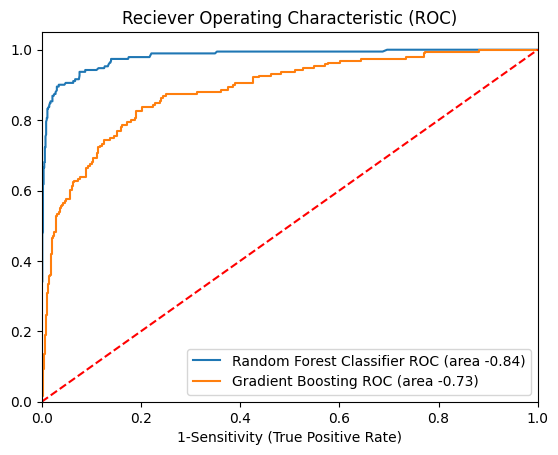

In [71]:

from sklearn.metrics import roc_auc_score,roc_curve
plt.figure()

auc_models = [
{
        'label':'Random Forest Classifier',
        "model":RandomForestClassifier(n_estimators=1000,min_samples_split=2,max_features=8,max_depth=None),
        'auc': 0.8424
},
{
        'label':'Gradient Boosting',
        "model":GradientBoostingClassifier(n_estimators= 100, max_features= 'log2', loss= 'log_loss', learning_rate= 0.5, criterion= 'friedman_mse'),
        'auc': 0.7337
}
    
]

## Create loop through all model
for algo in auc_models:
    model = algo['model'] ## select the model
    model.fit(X_train,y_train)  ## train the model
    
    ## compute False Positive Rate, and True Positive Rate
    fpr, tpr, thresholds = roc_curve(y_test,model.predict_proba(X_test)[:,1])
    
    ## Calculate Area Under the Curve to display on the plot
    plt.plot(fpr,tpr,label='%s ROC (area -%0.2f)' % (algo['label'],algo['auc']))
    
    
## Custom Setting for the plot
plt.plot([0,1],[0,1],'r--')
plt.xlim([0.0,1.0])
plt.ylim([0.0,1.05])

plt.xlabel('1-Specificity (False Positive Rate)')
plt.xlabel('1-Sensitivity (True Positive Rate)')
plt.title('Reciever Operating Characteristic (ROC)') 
plt.legend(loc='lower right')
plt.savefig('auc.png')
plt.show()

### This is the implimentation of Gradient Bossting for classification 